In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("marketing_data.csv")

In [3]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,Spain


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
## check for null values in columns
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

## Only income have null value

In [6]:
df.columns = df.columns.str.strip()

<Axes: xlabel='Income'>

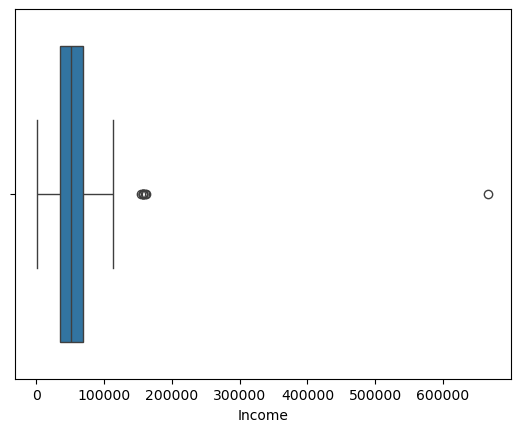

In [7]:
## Checking the outliers in income
sns.boxplot(x='Income',data=df)
## income have outliers but no need to remove them.

Before making any change in data make a copy of it and the making tha change in copyed data

In [8]:
df_copy=df.copy() 

In [9]:
## now we will fill the null values with income , since it have outlier we are filling it with median
df_copy['Income']=df_copy['Income'].fillna(df_copy.groupby('Education')['Income'].transform('median'))

In [10]:
## Calculate age
df_copy['age']=2014-df_copy['Year_Birth']


In [11]:
df_copy.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,age
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,1,0,0,0,0,0,1,0,Spain,44
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,5,0,0,0,0,1,1,0,Canada,53
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,2,0,0,0,0,0,0,0,USA,56
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,7,0,0,0,0,0,0,0,Australia,47
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,7,1,0,0,0,0,1,0,Spain,25


In [12]:
## Removing the year_Birth column
df_copy.drop('Year_Birth',axis=1,inplace=True)

<Axes: xlabel='age'>

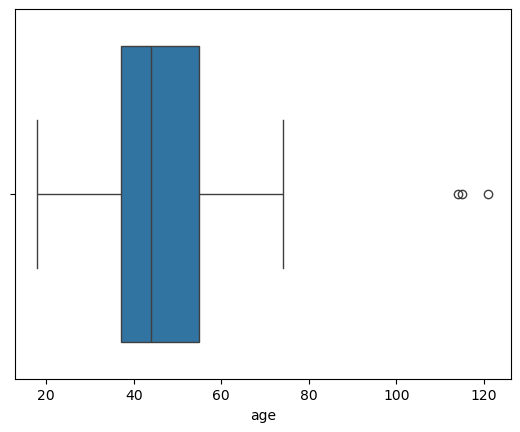

In [13]:
# checking the outliers in age column
sns.boxplot(x='age',data=df_copy)

In [14]:
# Age have 3 outliers and it better to cap(replace) them with boundry value
Q1=df_copy['age'].quantile(0.25)
Q3=df_copy['age'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

df_copy['age']=df_copy['age'].clip(lower_bound,upper_bound)

<Axes: xlabel='age'>

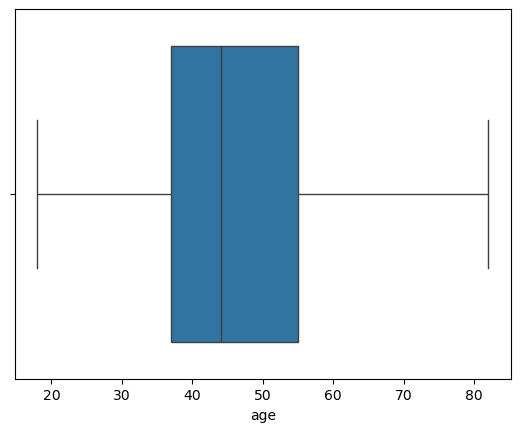

In [15]:
sns.boxplot(x='age',data=df_copy)

In [16]:
df_copy.describe()

,ID,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,age
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,52242.594866,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375,45.147768
std,3246.662198,25039.061738,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391,11.771725
min,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
25%,2828.250000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,37.000000
50%,5458.500000,51498.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,44.000000
75%,8427.750000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000
max,11191.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,82.000000


In [17]:
## lets create a age gorup column for better understanding of which age group are the main coustome
def gr(x):
    if x>=18 and x<25:
        return '18-25'
    elif x>=25 and x<45:
        return '25-45'
    elif x>=45 and x<60:
        return '45-60'
    else:
        return 'above 60'
df_copy['age_group']=df_copy['age'].apply(gr)

In [18]:
df_copy.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,age,age_group
0,1826,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,104,...,0,0,0,0,0,1,0,Spain,44,25-45
1,1,Graduation,Single,57091.0,0,0,2014-06-15,0,464,5,...,0,0,0,0,1,1,0,Canada,53,45-60
2,10476,Graduation,Married,67267.0,0,1,2014-05-13,0,134,11,...,0,0,0,0,0,0,0,USA,56,45-60
3,1386,Graduation,Together,32474.0,1,1,2014-05-11,0,10,0,...,0,0,0,0,0,0,0,Australia,47,45-60
4,5371,Graduation,Single,21474.0,1,0,2014-04-08,0,6,16,...,1,0,0,0,0,1,0,Spain,25,25-45


In [19]:
df_copy['Education'].unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [20]:
## since 2n cycle and master is same so replace it with master
df_copy['Education']=df_copy['Education'].replace({'2n Cycle':'Master'})

In [21]:
df_copy['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic'], dtype=object)

In [22]:
## check unique value in Marital_Status
df_copy['Marital_Status'].unique()

array(['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO',
       'Alone', 'Absurd'], dtype=object)

In [23]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64

In [24]:
df_copy['Marital_Status']=df_copy['Marital_Status'].replace({'Together':'Married','Alone':'Single','YOLO':'Single','Absurd':'Single'})

In [25]:
df_copy['Marital_Status'].unique()

array(['Divorced', 'Single', 'Married', 'Widow'], dtype=object)

In [26]:
df_copy['Dt_Customer']=pd.to_datetime(df_copy['Dt_Customer'])
df_copy['year']=df_copy['Dt_Customer'].dt.year
df_copy['month']=df_copy['Dt_Customer'].dt.month

In [27]:
df_copy.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,age,age_group,year,month
0,1826,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,104,...,0,0,0,1,0,Spain,44,25-45,2014,6
1,1,Graduation,Single,57091.0,0,0,2014-06-15,0,464,5,...,0,0,1,1,0,Canada,53,45-60,2014,6
2,10476,Graduation,Married,67267.0,0,1,2014-05-13,0,134,11,...,0,0,0,0,0,USA,56,45-60,2014,5
3,1386,Graduation,Married,32474.0,1,1,2014-05-11,0,10,0,...,0,0,0,0,0,Australia,47,45-60,2014,5
4,5371,Graduation,Single,21474.0,1,0,2014-04-08,0,6,16,...,0,0,0,1,0,Spain,25,25-45,2014,4


In [28]:
df_copy.drop('Dt_Customer',axis=1,inplace=True)

In [29]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2240 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   MntWines             2240 non-null   int64  
 8   MntFruits            2240 non-null   int64  
 9   MntMeatProducts      2240 non-null   int64  
 10  MntFishProducts      2240 non-null   int64  
 11  MntSweetProducts     2240 non-null   int64  
 12  MntGoldProds         2240 non-null   int64  
 13  NumDealsPurchases    2240 non-null   int64  
 14  NumWebPurchases      2240 non-null   int64  
 15  NumCatalogPurchases  2240 non-null   i

In [30]:
df_copy['year'].unique()

array([2014, 2013, 2012], dtype=int32)

In [31]:
## Checking the duplicates 
print(df_copy.duplicated().sum())

0


In [32]:
numerical_col=[feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
catagorical_col=[feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

print('We have {} numerical Column: {}'.format(len(numerical_col),numerical_col))
print('We have {} catagorical Column: {}'.format(len(catagorical_col),catagorical_col))

We have 26 numerical Column: ['ID', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'age', 'year', 'month']
We have 4 catagorical Column: ['Education', 'Marital_Status', 'Country', 'age_group']


C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3970055577.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[cam_resp[i]],shade=True,color='r')
C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3970055577.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[cam_resp[i]],shade=True,color='r')
C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3970055577.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[cam_resp[i]],shade=True,color='r')
C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3970055577.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will becom

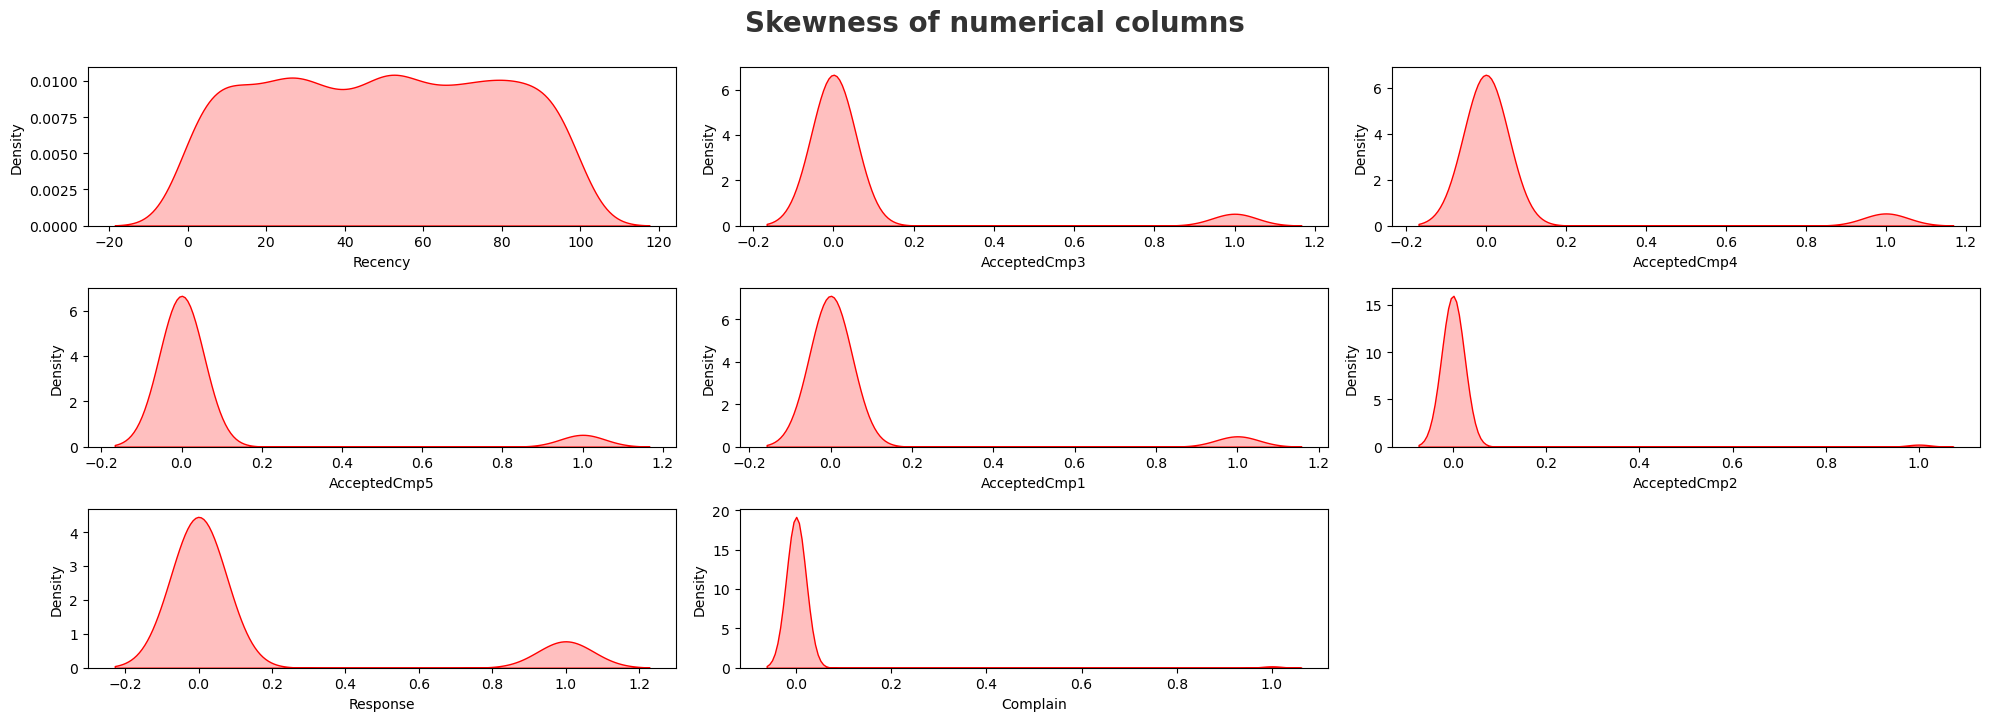

In [34]:
plt.figure(figsize=(20,20))
plt.suptitle('Skewness of numerical columns',fontsize=20,fontweight='bold',alpha=0.8,y=1.)

cam_resp=['Recency','AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain']
for i in range(0,len(cam_resp)):
    plt.subplot(9,3,i+1)
    sns.kdeplot(x=df_copy[cam_resp[i]],shade=True,color='r')
    plt.xlabel(cam_resp[i])
    plt.tight_layout()

### Observation

Recency is approximately uniformly distributed, indicating a balanced mix of recently active and inactive customers.The low campaign acceptance rates suggest an opportunity to improve campaign targeting through customer segmentation and personalized marketing.
The Complain variable is extremely imbalanced, indicating that customer complaints are very rare.

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3134789116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[catagorical_col[i]],palette="Set2")
C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3134789116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[catagorical_col[i]],palette="Set2")
C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3134789116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[catagorical_col[i]],palette="Set2")
C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3134789116.py:5: FutureWar

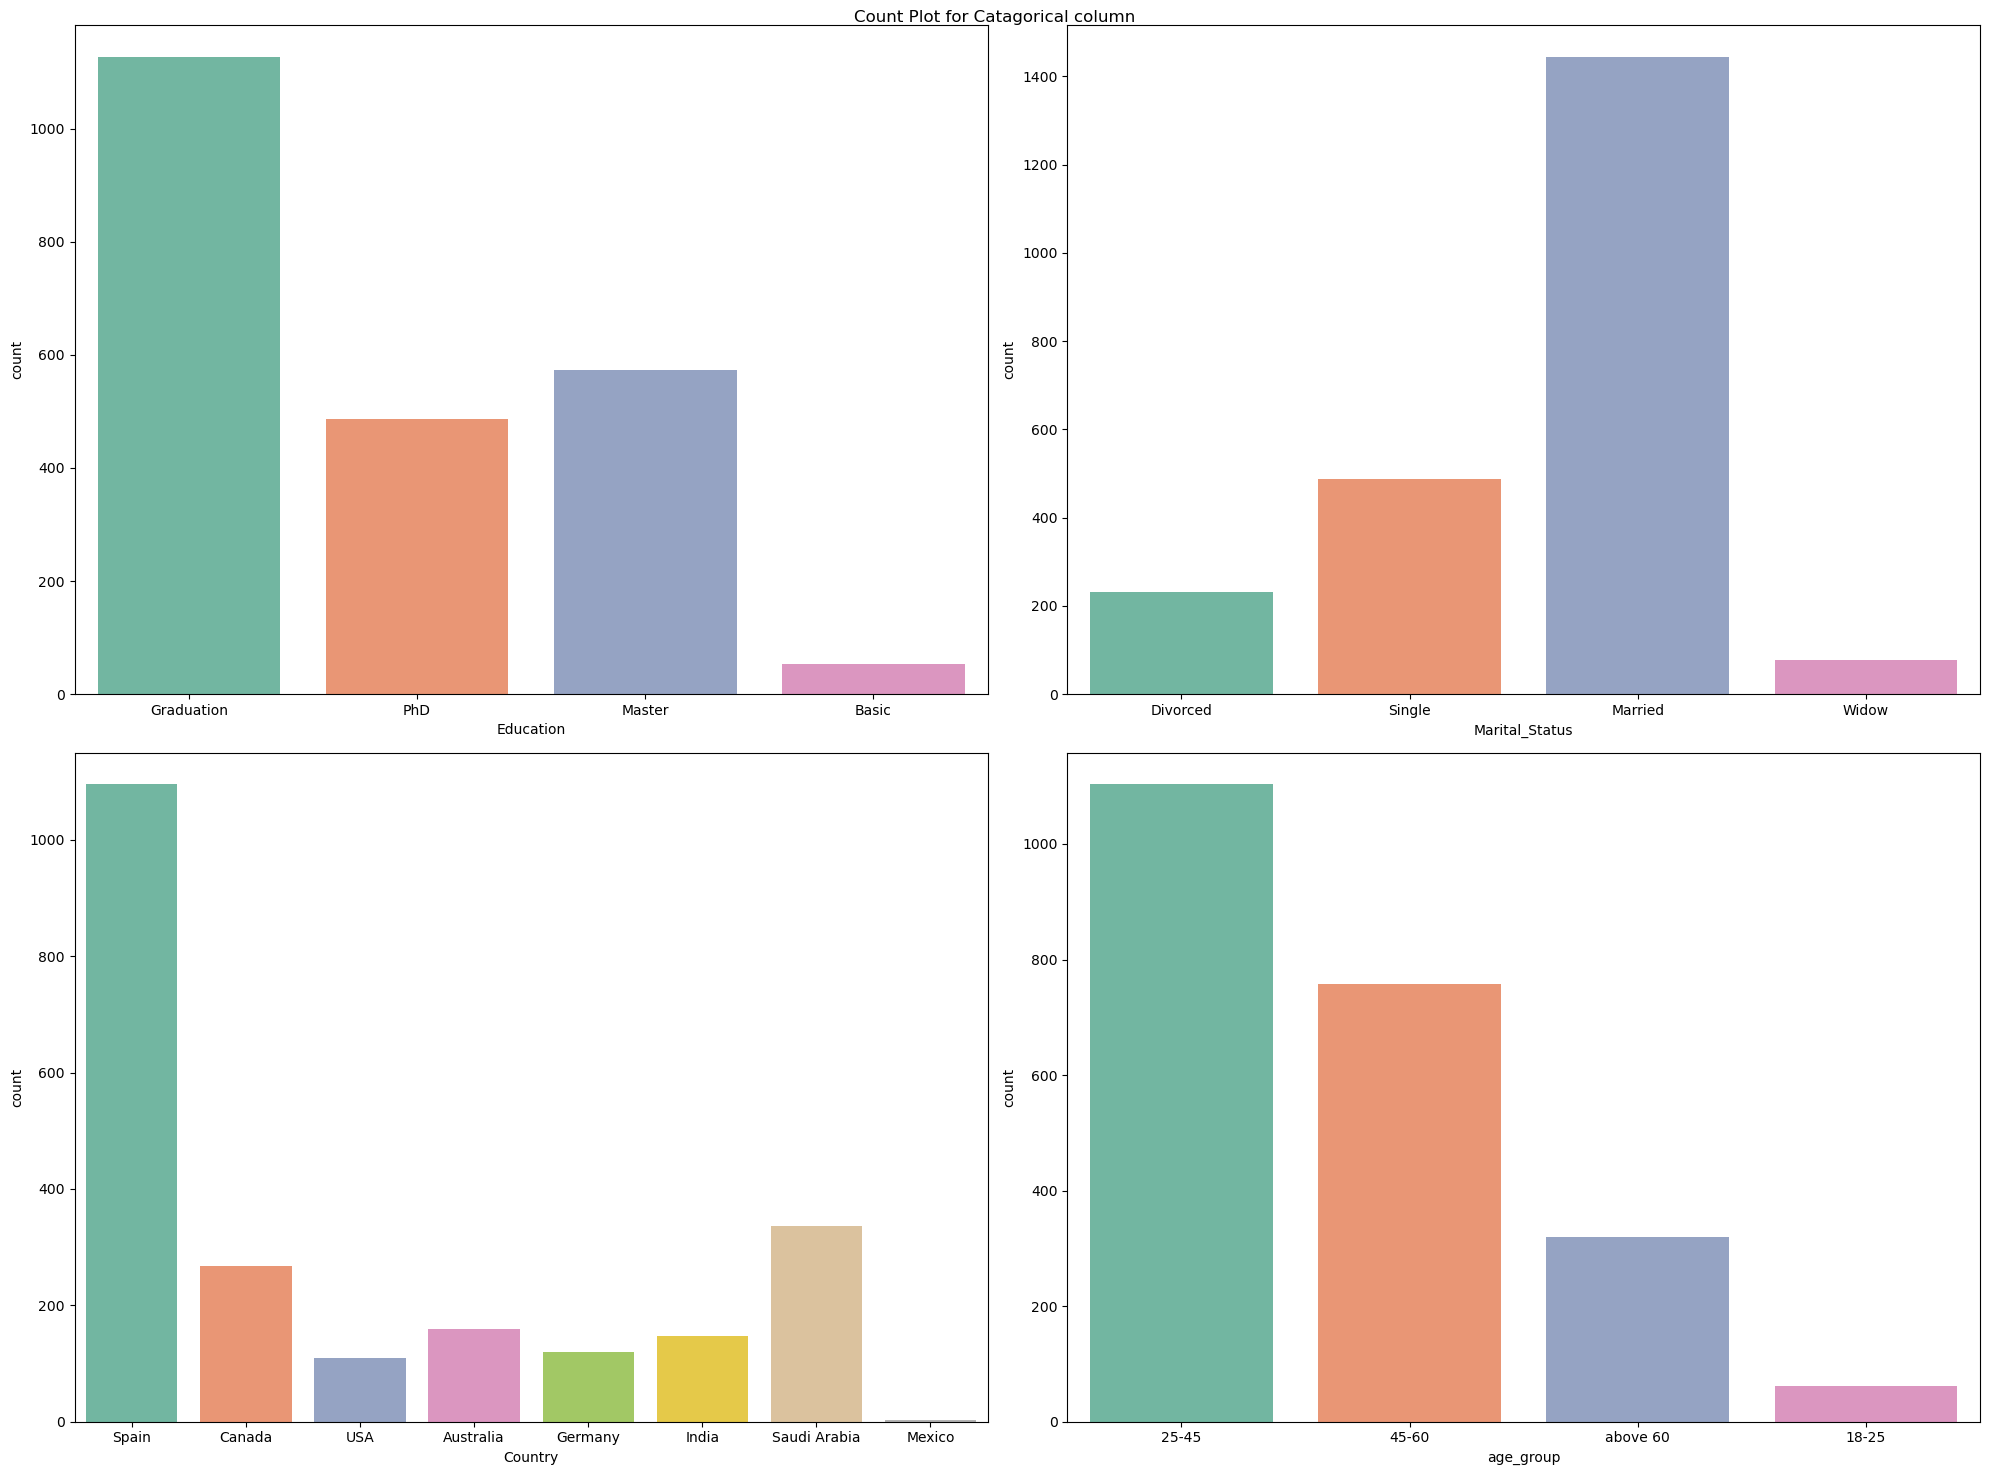

In [36]:
plt.figure(figsize=(20,15))
plt.suptitle('Count Plot for Catagorical column')
for i in range(0,len(catagorical_col)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df_copy[catagorical_col[i]],palette="Set2")
    plt.xlabel(catagorical_col[i])
    plt.tight_layout()

In [37]:
cat_list=['Education', 'Marital_Status', 'Country', 'age_group']
for col in cat_list:
    print(df_copy[col].value_counts(normalize=True)*100)
    print('------------------------------------')

Education
Graduation    50.312500
Master        25.580357
PhD           21.696429
Basic          2.410714
Name: proportion, dtype: float64
------------------------------------
Marital_Status
Married     64.464286
Single      21.741071
Divorced    10.357143
Widow        3.437500
Name: proportion, dtype: float64
------------------------------------
Country
Spain           48.883929
Saudi Arabia    15.044643
Canada          11.964286
Australia        7.142857
India            6.607143
Germany          5.357143
USA              4.866071
Mexico           0.133929
Name: proportion, dtype: float64
------------------------------------
age_group
25-45       49.241071
45-60       33.794643
above 60    14.241071
18-25        2.723214
Name: proportion, dtype: float64
------------------------------------


The customer base is dominated by Graduates (50.3%), followed by customers with Master's (25.6%) and PhD (21.7%) qualifications.

Married customers (64.5%) constitute the largest marital segment, significantly outnumbering Single, Divorced, and Widowed customers.

Spain accounts for nearly half of the customer base (48.9%), making it the primary market in the dataset.

The 25–45 age group (49.2%) represents the largest customer segment, followed by customers aged 45–60 (33.8%).

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\4125153914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group',y='MntWines',data=avg_spent_wine,palette='Set2')


<Axes: xlabel='age_group', ylabel='MntWines'>

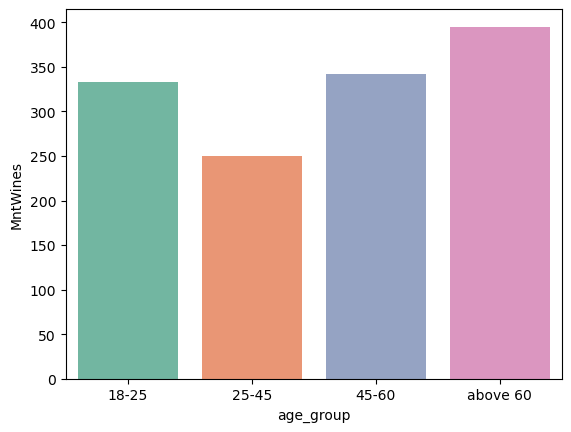

In [38]:
avg_spent_wine=df_copy.groupby('age_group')['MntWines'].mean().reset_index()

sns.barplot(x='age_group',y='MntWines',data=avg_spent_wine,palette='Set2')

([<matplotlib.patches.Wedge at 0x1d9e9a65f70>,
 [Text(1.095168417255446, 0.1029861051123009, '18-25'),
  Text(0.1220115617520196, 1.093212321005775, '25-45'),
  Text(-0.7786889921101526, -0.7769449488647666, '45-60'),
  Text(0.9191371555404396, -0.6043069495753212, 'above 60')],
 [Text(0.5973645912302431, 0.05617423915216412, '3.0%'),
  Text(0.06655176095564705, 0.5962976296395135, '40.5%'),
  Text(-0.4247394502419014, -0.4237881539262363, '38.0%'),
  Text(0.5013475393856943, -0.3296219724956297, '18.5%')])

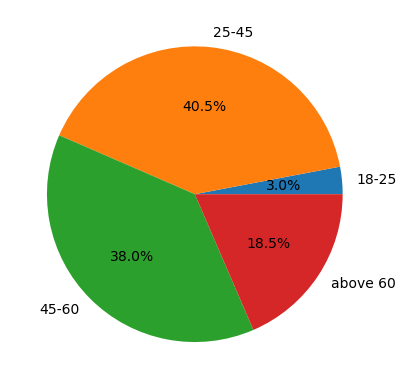

In [39]:
total_spent_wine=df_copy.groupby('age_group')['MntWines'].sum().reset_index()

plt.pie(total_spent_wine['MntWines'],labels=total_spent_wine['age_group'],autopct='%1.1f%%')

#### Wine Spending by Age Group

* The 25–45 age group generates the highest wine revenue (40.5%), making it the most valuable customer segment for wine sales.
* Customers above 60 have the highest average wine spending per customer, indicating strong purchasing potential despite their smaller population size.
* To increase wine sales, personalized promotions and targeted campaigns should primarily focus on the 25–45 and 45–60 age groups, as they contribute nearly 80% of total wine revenue.
* Premium wine offers, loyalty rewards, and exclusive discounts can be targeted toward the above 60 segment to further leverage their high spending behavior.


C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3240152441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group',y='MntFruits',data=avg_spent_fr,palette='Set2')


<Axes: xlabel='age_group', ylabel='MntFruits'>

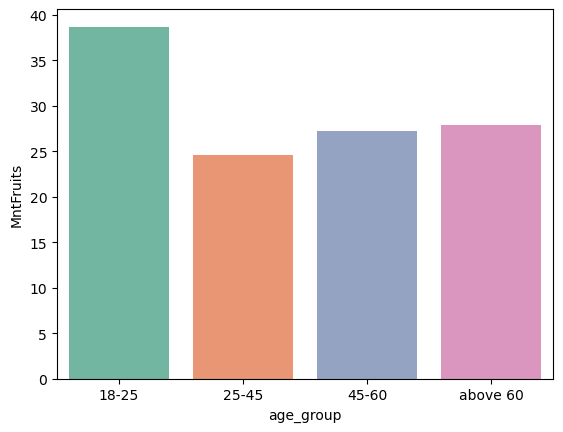

In [40]:
avg_spent_fr=df_copy.groupby('age_group')['MntFruits'].mean().reset_index()

sns.barplot(x='age_group',y='MntFruits',data=avg_spent_fr,palette='Set2')


([<matplotlib.patches.Wedge at 0x1d9e9b13770>,
 [Text(1.091301747514918, 0.13805975471108928, '18-25'),
  Text(-0.1361103139110534, 1.0915466011339299, '25-45'),
  Text(-0.5044495884590282, -0.9775124616614957, '45-60'),
  Text(0.9784120476402685, -0.5027025611953625, 'above 60')],
 [Text(0.5952554986445007, 0.07530532075150324, '4.0%'),
  Text(-0.07424198940602912, 0.5953890551639617, '45.9%'),
  Text(-0.27515432097765175, -0.5331886154517249, '34.9%'),
  Text(0.5336792987128737, -0.27420139701565227, '15.1%')])

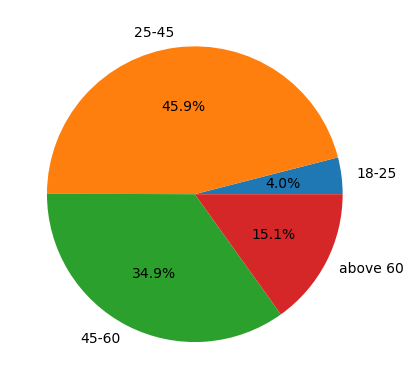

In [41]:
total_spent_fr=df_copy.groupby('age_group')['MntFruits'].sum().reset_index()

plt.pie(total_spent_fr['MntFruits'],labels=total_spent_fr['age_group'],autopct='%1.1f%%')


 Personalized promotions should focus on the 25–45(45.9%) and 45–60(34.9%) age groups to maximize overall fruit sales.

 Premium or health-focused fruit offers can be targeted at the 18–25 segment to capitalize on their higher average spending.


C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3295700785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group',y='MntMeatProducts',data=avg_spent_meat,palette='Set2')


<Axes: xlabel='age_group', ylabel='MntMeatProducts'>

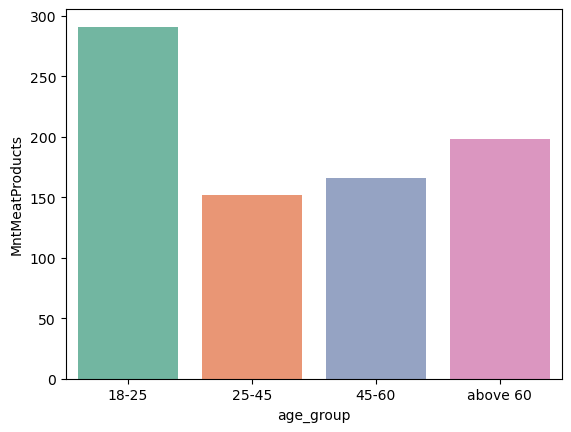

In [42]:
avg_spent_meat=df_copy.groupby('age_group')['MntMeatProducts'].mean().reset_index()

sns.barplot(x='age_group',y='MntMeatProducts',data=avg_spent_meat,palette='Set2')

([<matplotlib.patches.Wedge at 0x1d9e99bf470>,
 [Text(1.087790915186807, 0.1634347724232796, '18-25'),
  Text(-0.14867136415196625, 1.0899067966946503, '25-45'),
  Text(-0.56905383773134, -0.9413701343059668, '45-60'),
  Text(0.9489991817103757, -0.5562378565982702, 'above 60')],
 [Text(0.5933404991928037, 0.08914623950360706, '4.7%'),
  Text(-0.08109347135561795, 0.5944946163789001, '44.8%'),
  Text(-0.31039300239891265, -0.5134746187123455, '33.6%'),
  Text(0.5176359172965684, -0.30340246723542, '16.9%')])

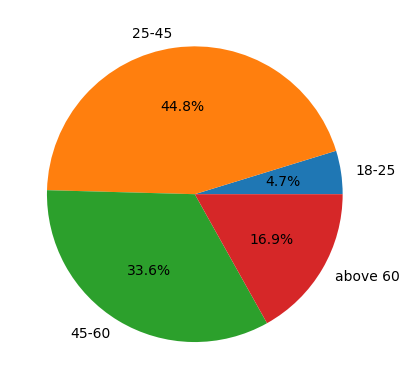

In [43]:
total_spent_meat=df_copy.groupby('age_group')['MntMeatProducts'].sum().reset_index()

plt.pie(total_spent_meat['MntMeatProducts'],labels=total_spent_meat['age_group'],autopct='%1.1f%%')


Personalized promotions should focus on the 25–45(44.8%) and 45–60(33.6%) age groups to maximize meat product sales.

Premium product recommendations and targeted offers can be used to further engage the 18–25 segment and increase overall revenue.

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\1298013709.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group',y='MntFishProducts',data=avg_spent_fish,palette='Set2')


<Axes: xlabel='age_group', ylabel='MntFishProducts'>

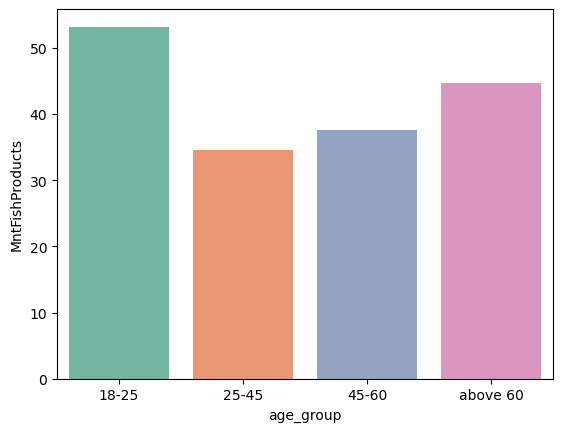

In [44]:
avg_spent_fish=df_copy.groupby('age_group')['MntFishProducts'].mean().reset_index()

sns.barplot(x='age_group',y='MntFishProducts',data=avg_spent_fish,palette='Set2')

([<matplotlib.patches.Wedge at 0x1d9eb6ccaa0>,
 [Text(1.091919994583326, 0.1330816494831254, '18-25'),
  Text(-0.10666175319971229, 1.0948165464608048, '25-45'),
  Text(-0.5814124412270603, -0.9337877559629867, '45-60'),
  Text(0.9475624369155321, -0.5586818666707365, 'above 60')],
 [Text(0.5955927243181778, 0.0725899906271593, '3.9%'),
  Text(-0.058179138108933964, 0.5971726617058936, '45.4%'),
  Text(-0.3171340588511238, -0.5093387759798108, '33.8%'),
  Text(0.5168522383175629, -0.3047355636385835, '17.0%')])

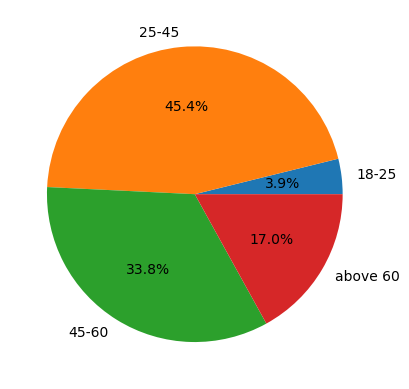

In [45]:
total_spent_fish=df_copy.groupby('age_group')['MntFishProducts'].sum().reset_index()

plt.pie(total_spent_fish['MntFishProducts'],labels=total_spent_fish['age_group'],autopct='%1.1f%%')


Personalized promotions should primarily target the 25–45(45.4%) and 45–60(33.8%) age groups to maximize fish product revenue.

Targeted premium offers can be used to further increase spending among the 18–25 segment as they have highest average spending 

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3993239095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group',y='MntSweetProducts',data=avg_spent_sw,palette='Set2')


<Axes: xlabel='age_group', ylabel='MntSweetProducts'>

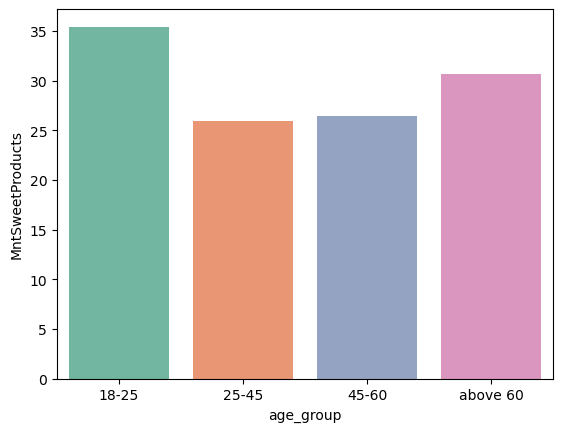

In [46]:
avg_spent_sw=df_copy.groupby('age_group')['MntSweetProducts'].mean().reset_index()

sns.barplot(x='age_group',y='MntSweetProducts',data=avg_spent_sw,palette='Set2')

([<matplotlib.patches.Wedge at 0x1d9eb77cd10>,
 [Text(1.0931091653754887, 0.12293230890251139, '18-25'),
  Text(-0.14977228963228145, 1.0897560558484198, '25-45'),
  Text(-0.5105485915482181, -0.9743408724199817, '45-60'),
  Text(0.961493010166468, -0.5343511873300408, 'above 60')],
 [Text(0.5962413629320847, 0.06705398667409711, '3.6%'),
  Text(-0.08169397616306259, 0.594412394099138, '47.2%'),
  Text(-0.27848104993539163, -0.5314586576836263, '33.1%'),
  Text(0.5244507328180734, -0.29146428399820407, '16.1%')])

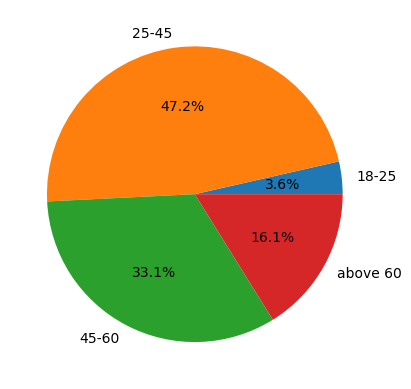

In [47]:
total_spent_sw=df_copy.groupby('age_group')['MntSweetProducts'].sum().reset_index()

plt.pie(total_spent_sw['MntSweetProducts'],labels=total_spent_sw['age_group'],autopct='%1.1f%%')


Customers aged 18–25 have the highest average spending on sweet products, indicating strong spending potential on a per-customer basis.

Marketing efforts should focus on the 25–45(47.2%) and 45–60(33.1%) age groups to maximize sweet product sales.

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\3970440859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group',y='MntGoldProds',data=avg_spent_gold,palette='Set2')


<Axes: xlabel='age_group', ylabel='MntGoldProds'>

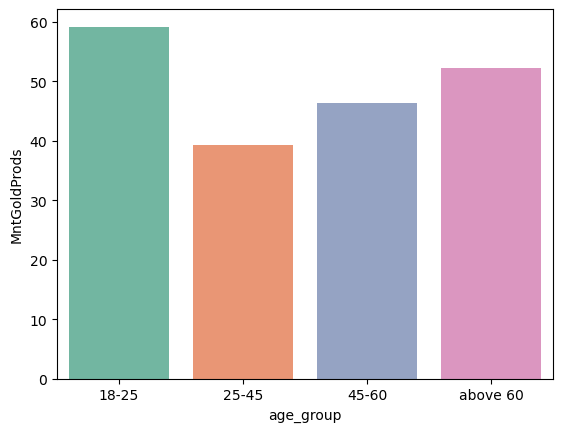

In [48]:
avg_spent_gold=df_copy.groupby('age_group')['MntGoldProds'].mean().reset_index()

sns.barplot(x='age_group',y='MntGoldProds',data=avg_spent_gold,palette='Set2')

([<matplotlib.patches.Wedge at 0x1d9e9d30f20>,
 [Text(1.0927408768529427, 0.12616408385377303, '18-25'),
  Text(-0.04122101333276888, 1.0992273777794201, '25-45'),
  Text(-0.6278160042959962, -0.9032425282003775, '45-60'),
  Text(0.9491190458325803, -0.5560333055113268, 'above 60')],
 [Text(0.5960404782834233, 0.06881677301114893, '3.7%'),
  Text(-0.02248418909060121, 0.5995785696978654, '43.9%'),
  Text(-0.3424450932523615, -0.49267774265475134, '35.6%'),
  Text(0.5177012977268619, -0.3032908939152691, '16.9%')])

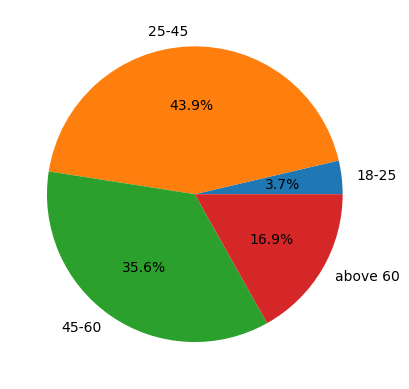

In [49]:
total_spent_gold=df_copy.groupby('age_group')['MntGoldProds'].sum().reset_index()

plt.pie(total_spent_gold['MntGoldProds'],labels=total_spent_sw['age_group'],autopct='%1.1f%%')


Customers aged 18–25 have the highest average spending on gold products, indicating strong spending potential at an individual level.

Personalized promotions should focus on the 25–45(43.9%) and 45–60(35.6%) age groups to maximize gold product revenue.

##### Overall Business Insights by Age Group

The 25–45 age group is the primary revenue driver across all product categories, contributing approximately 44–47% of total revenue for Wines, Fruits, Meat, Fish, Sweet Products, and Gold Products.

The 45–60 age group consistently ranks second, contributing 33–38% of total revenue, making it another high-value customer segment.

Although the 18–25 age group contributes the lowest overall revenue, it records the highest average spending per customer across most product categories, indicating strong untapped potential.

Customers above 60 show relatively high average spending, particularly for premium categories such as Wines and Gold Products, despite their smaller contribution to total revenue.

In [50]:
most_spend=df_copy[[
    'MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'
]].sum().sort_values(ascending=False)

print(most_spend)

MntWines            680816
MntMeatProducts     373968
MntGoldProds         98609
MntFishProducts      84057
MntSweetProducts     60621
MntFruits            58917
dtype: int64


In [51]:
avg_spend=df_copy[[
    'MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'
]].mean().sort_values(ascending=False)

print(avg_spend)

MntWines            303.935714
MntMeatProducts     166.950000
MntGoldProds         44.021875
MntFishProducts      37.525446
MntSweetProducts     27.062946
MntFruits            26.302232
dtype: float64


Wine products generate the highest revenue among all product categories, indicating strong customer preference and making it the most important category for revenue generation. Meat Products rank second, while Gold, Fish, Sweet Products, and Fruits Products contribute comparatively less to overall sales.

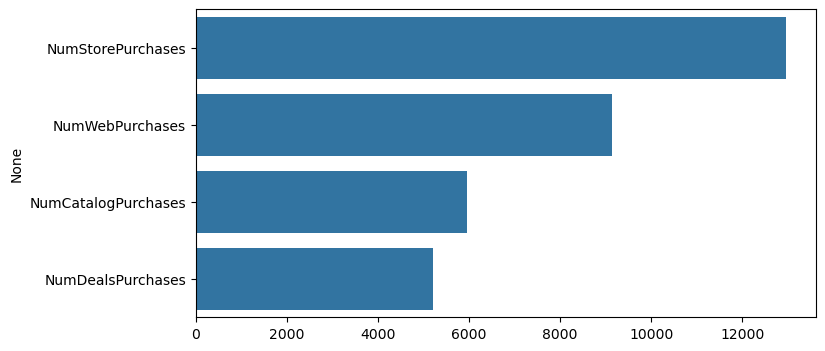

NumStorePurchases      12970
NumWebPurchases         9150
NumCatalogPurchases     5963
NumDealsPurchases       5208
dtype: int64


In [52]:
## Purchase platform
platform_prefered=df_copy[['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=platform_prefered.values,y=platform_prefered.index)
plt.show()
print(platform_prefered)

The results suggest that customers still prefer the in-store shopping experience, while the website serves as an important secondary sales channel.
To increase overall sales, the company should focus on enhancing in-store customer experience and use personalized online promotions to further drive web purchases.

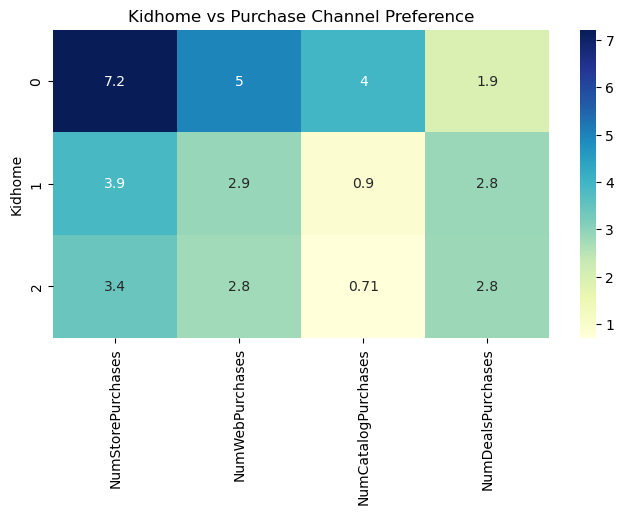

In [53]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.groupby('Kidhome')[[
        'NumStorePurchases',
        'NumWebPurchases',
        'NumCatalogPurchases',
        'NumDealsPurchases'
    ]].mean(),
    annot=True,
    cmap='YlGnBu'
)

plt.title('Kidhome vs Purchase Channel Preference')
plt.show()

Store-based promotions should remain the primary strategy across all household segments, as in-store shopping is the preferred channel regardless of the number of children.

Family-oriented discounts and bundle offers can be targeted at households with children (Kidhome = 1 and Kidhome = 2) to increase purchase frequency.

Customers without children represent the most engaged segment and can be targeted with personalized cross-selling and loyalty campaigns to maximize revenue.

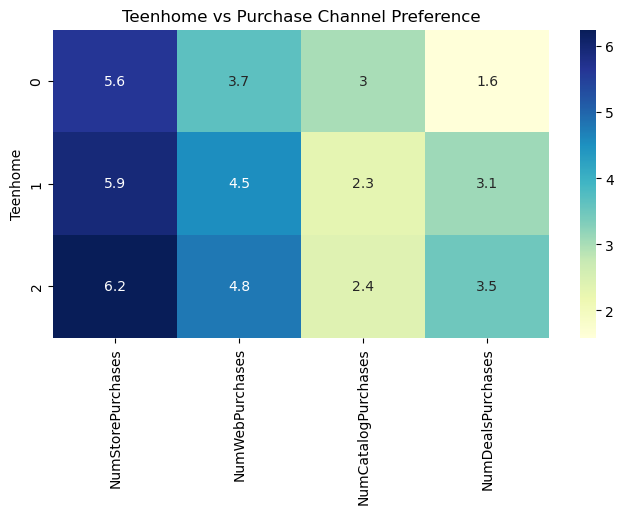

In [76]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.groupby('Teenhome')[[
        'NumStorePurchases',
        'NumWebPurchases',
        'NumCatalogPurchases',
        'NumDealsPurchases'
    ]].mean(),
    annot=True,
    cmap='YlGnBu'
)

plt.title('Teenhome vs Purchase Channel Preference')
plt.show()

Households with teenagers are more active shoppers, particularly through web and discount channels, while in-store purchases remain the preferred shopping method overall. This segment presents a strong opportunity for targeted digital marketing and promotional campaigns.

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\150087860.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_spending = df_copy.groupby('Income_Group')['Total_Spending'].mean().reset_index()


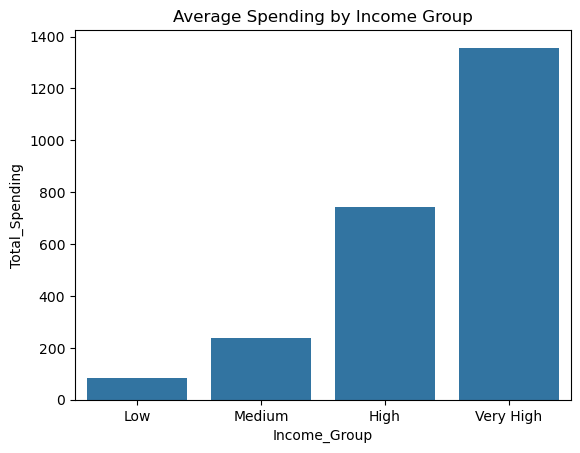

In [56]:
df_copy['Total_Spending'] = (
    df_copy['MntWines'] + df_copy['MntFruits'] + df_copy['MntMeatProducts'] +
    df_copy['MntFishProducts'] + df_copy['MntSweetProducts'] + df_copy['MntGoldProds']
)

df_copy['Income_Group'] = pd.qcut(
    df_copy['Income'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

income_spending = df_copy.groupby('Income_Group')['Total_Spending'].mean().reset_index()

sns.barplot(
    x='Income_Group',
    y='Total_Spending',
    data=income_spending
)
plt.title('Average Spending by Income Group')
plt.show()

Income is a strong driver of customer spending. High and Very High Income customers are the most valuable segments and should be prioritized for personalized marketing and premium product recommendations.

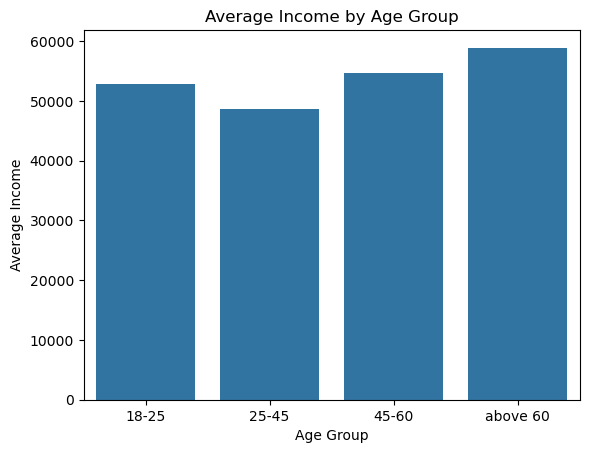

  age_group        Income
0     18-25  52877.000000
1     25-45  48639.712602
2     45-60  54642.632761
3  above 60  58883.509404


In [57]:
avg_income_age = df_copy.groupby('age_group')['Income'].mean().reset_index()

sns.barplot(
    x='age_group',
    y='Income',
    data=avg_income_age
)

plt.title('Average Income by Age Group')
plt.ylabel('Average Income')
plt.xlabel('Age Group')
plt.show()
print(avg_income_age)

Customers above 60 have the highest average income ($58.9K), followed by the 45–60 age group ($54.6K).
The 18–25 age group has an average income of $52.9K, while the 25–45 age group records the lowest average income ($48.6K).

<Axes: >

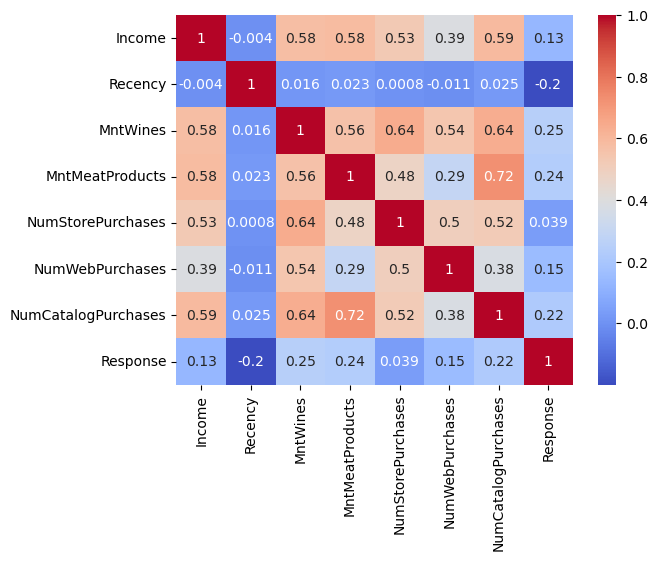

In [58]:
corr = df[['Income',
           'Recency',
           'MntWines',
           'MntMeatProducts',
           'NumStorePurchases',
           'NumWebPurchases',
           'NumCatalogPurchases',
           'Response']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')

Income has a strong positive correlation with customer spending, particularly for Catalog Purchases (0.59), Wine Spending (0.58), Meat Spending (0.58), and Store Purchases (0.53), indicating that higher-income customers tend to spend more.

Meat Products and Catalog Purchases show the strongest positive correlation (0.72), suggesting that customers purchasing meat products frequently use the catalog channel.

Wine Spending is positively correlated with both Store Purchases (0.64) and Catalog Purchases (0.64), indicating that wine buyers are active across these purchase channels.

Store Purchases and Web Purchases exhibit a moderate positive correlation (0.50), suggesting that customers often shop through multiple channels rather than relying on a single one.

Recency has a weak negative correlation with Response (-0.20), indicating that customers who purchased more recently are slightly more likely to respond to marketing campaigns.

Response has only weak positive correlations with spending and purchase variables (0.13–0.25), suggesting that campaign acceptance depends on additional customer characteristics beyond purchase behavior.

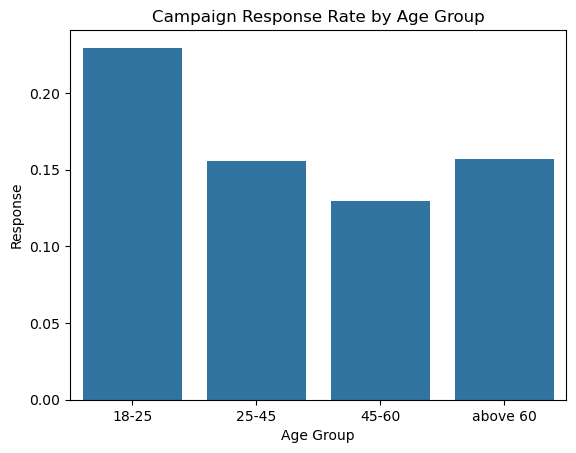

In [69]:
age_res2=df_copy.groupby('age_group')['Response'].mean().reset_index()


sns.barplot(x='age_group',y='Response',data=age_res2)
plt.title('Campaign Response Rate by Age Group')
plt.xlabel('Age Group')
plt.show()

The 18–25 segment is the easiest to convert through marketing campaigns, while the 25–45 segment offers the greatest revenue potential. Marketing efforts should focus on increasing conversion in the 25–45 segment while using engaging promotional campaigns to attract and retain younger customers.

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\1189679348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Education',y='Response',data=ed_res,palette='pink')


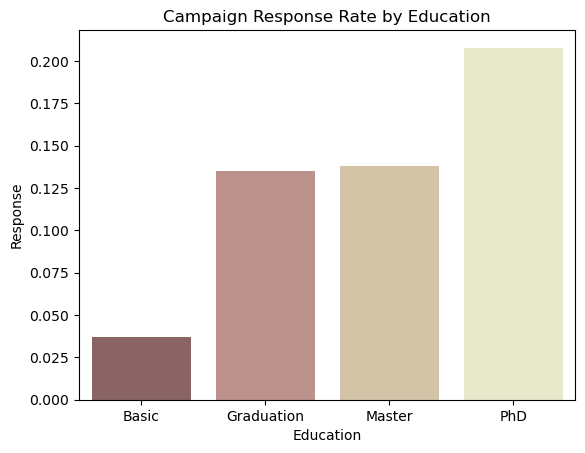

In [70]:
ed_res=df_copy.groupby('Education')['Response'].mean().reset_index()


sns.barplot(x='Education',y='Response',data=ed_res,palette='pink')
plt.title('Campaign Response Rate by Education')
plt.xlabel('Education')
plt.show()

PhD customers have the highest likelihood of responding to campaigns, while Graduates remain the most valuable target due to their larger customer base. Marketing efforts should prioritize personalized campaigns for Graduates and premium offers for PhD customers.

C:\Users\hp\AppData\Local\Temp\ipykernel_20664\167249543.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Marital_Status',y='Response',data=m_res,palette='Set1')


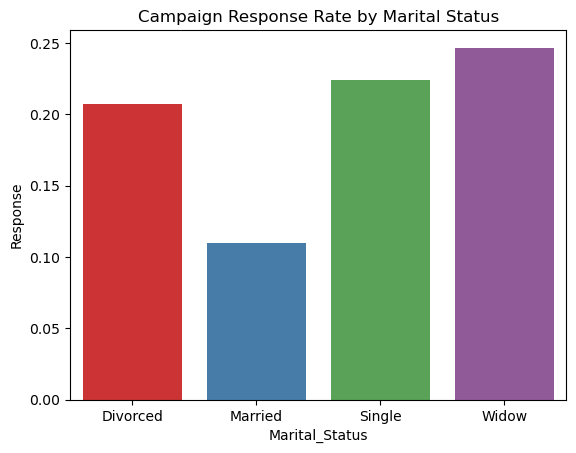

In [74]:
m_res=df_copy.groupby('Marital_Status')['Response'].mean().reset_index()


sns.barplot(x='Marital_Status',y='Response',data=m_res,palette='Set1')
plt.title('Campaign Response Rate by Marital Status')
plt.xlabel('Marital_Status')
plt.show()

Widowed customers are the most responsive to marketing campaigns, while Married customers offer the greatest opportunity for improving campaign performance due to their large population.

In [77]:
df_copy.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp2,Response,Complain,Country,age,age_group,year,month,Income_Group,Total_Spending
0,1826,Graduation,Divorced,84835.0,0,0,0,189,104,379,...,0,1,0,Spain,44,25-45,2014,6,Very High,1190
1,1,Graduation,Single,57091.0,0,0,0,464,5,64,...,1,1,0,Canada,53,45-60,2014,6,High,577
2,10476,Graduation,Married,67267.0,0,1,0,134,11,59,...,0,0,0,USA,56,45-60,2014,5,High,251
3,1386,Graduation,Married,32474.0,1,1,0,10,0,1,...,0,0,0,Australia,47,45-60,2014,5,Low,11
4,5371,Graduation,Single,21474.0,1,0,0,6,16,24,...,0,1,0,Spain,25,25-45,2014,4,Low,91


C:\Users\hp\AppData\Local\Temp\ipykernel_20664\4183898439.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_res=df_copy.groupby('Income_Group')['Response'].mean().reset_index()
C:\Users\hp\AppData\Local\Temp\ipykernel_20664\4183898439.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Income_Group',y='Response',data=income_res,palette='Set3')


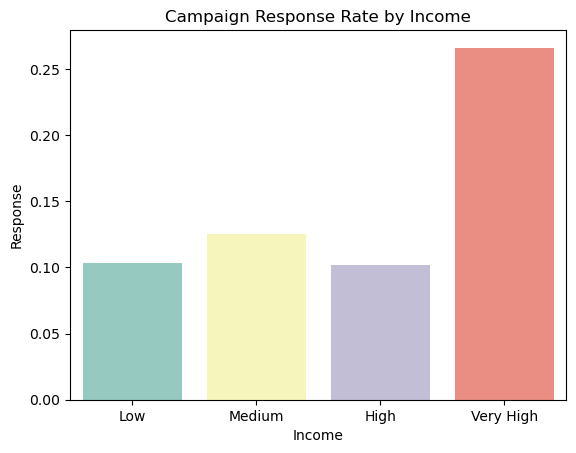

In [79]:
income_res=df_copy.groupby('Income_Group')['Response'].mean().reset_index()


sns.barplot(x='Income_Group',y='Response',data=income_res,palette='Set3')
plt.title('Campaign Response Rate by Income')
plt.xlabel('Income')
plt.show()

Very High income customers are the most responsive to campaigns, making them the ideal target for premium and personalized offers, while the High income segment presents an opportunity to increase campaign effectiveness through better-targeted promotions.